# IELTS Model Performance & Augmentation Analysis

This notebook provides a comprehensive analysis of the IELTS scoring model's training dynamics, including:
1. **Learning Rate & Momentum** — Visualize AdamW optimizer parameters
2. **Training & Validation Accuracy** — Per-epoch metrics for all 4 IELTS criteria
3. **Weights & Biases** — Inspect and visualize model parameters
4. **Data Augmentation** — Experiment with augmented data and measure impact

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer, util
import spacy
from spellchecker import SpellChecker
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import copy
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

d:\Projects\Senior-Capstone-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
# Load NLP tools
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

spell = SpellChecker()
sim_model = SentenceTransformer('all-mpnet-base-v2')
print('NLP tools loaded')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 397.33it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLP tools loaded


In [3]:
# Model Architecture (same as advanced_model.py)

def extract_advanced_features(row):
    essay = str(row.get('Essay_Text', ''))
    prompt = str(row.get('Question', ''))
    doc = nlp(essay)

    lengths = [len(s) for s in doc.sents]
    var = np.var(lengths) if lengths else 0
    dep_clauses = sum(1 for t in doc if t.dep_ in ['advcl', 'relcl', 'ccomp'])

    tokens = [t.text.lower() for t in doc if t.is_alpha]
    unique = set(tokens)
    ttr = len(unique) / len(tokens) if tokens else 0
    misspelled = len(spell.unknown(tokens)) / len(tokens) if tokens else 0

    sim = 0.0
    if essay and prompt:
        e_emb = sim_model.encode(essay, convert_to_numpy=True)
        p_emb = sim_model.encode(prompt, convert_to_numpy=True)
        sim = util.cos_sim(e_emb, p_emb).item()

    return [float(var), float(dep_clauses), float(ttr), float(misspelled), float(sim)]


class IELTSMultiTaskModel(nn.Module):
    def __init__(self, n_extra_features):
        super(IELTSMultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(0.3)
        input_size = self.bert.config.hidden_size + n_extra_features

        self.ta_head = nn.Linear(input_size, 1)
        self.cc_head = nn.Linear(input_size, 1)
        self.lr_head = nn.Linear(input_size, 1)
        self.gra_head = nn.Linear(input_size, 1)

    def forward(self, ids, mask, feats):
        out = self.bert(ids, attention_mask=mask)
        pooled = self.drop(out.pooler_output)
        combined = torch.cat((pooled, feats), dim=1)
        return (self.ta_head(combined), self.cc_head(combined),
                self.lr_head(combined), self.gra_head(combined)), combined


class EssayDataset(Dataset):
    def __init__(self, texts, features, targets, tokenizer):
        self.texts = texts
        self.features = np.array(features, dtype=np.float32)
        self.targets = np.array(targets, dtype=np.float32)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            max_length=512,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'ids': enc['input_ids'].flatten(),
            'mask': enc['attention_mask'].flatten(),
            'feats': torch.tensor(self.features[i], dtype=torch.float),
            'targets': torch.tensor(self.targets[i], dtype=torch.float)
        }

print('Model architecture defined')

Model architecture defined


In [4]:
# Load & Prepare Data 
BASE_DIR = r'D:\Projects\Senior-Capstone-Project'

df1 = pd.read_csv(os.path.join(BASE_DIR, 'Datasets', 'Scraping Data', 'combined_ielts_essays_fixed.csv'))
df2 = pd.read_csv(os.path.join(BASE_DIR, 'Datasets', 'AI Generated Dataset', 'ielts_gemini_fixed.csv'))
df = pd.concat([df1, df2]).dropna(subset=[
    'Essay_Text', 'Question',
    'Task_Achievement', 'Coherence_Cohesion', 'Lexical_Resource', 'Grammar_Range'
])

CRITERIA = ['Task_Achievement', 'Coherence_Cohesion', 'Lexical_Resource', 'Grammar_Range']
CRITERIA_SHORT = ['TA', 'CC', 'LR', 'GRA']

print(f'Total essays loaded: {len(df)}')
df[CRITERIA].describe().round(2)

Total essays loaded: 585


,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Grammar_Range
count,585.00,585.00,585.00,585.00
mean,7.03,6.84,6.65,6.92
std,1.39,1.41,1.66,1.59
min,4.00,4.00,4.00,4.00
25%,6.00,6.00,5.50,6.00
50%,7.00,7.00,7.00,7.00
75%,8.00,8.00,8.00,8.50
max,9.00,9.00,9.00,9.00


In [5]:
# Feature Extraction
print('Extracting linguistic features (this may take a few minutes)...')
feature_list = df.apply(extract_advanced_features, axis=1).tolist()
feats = np.array(feature_list)

scaler = StandardScaler()
feats_scaled = scaler.fit_transform(feats)

targets = df[CRITERIA].values
texts = df['Essay_Text'].values

# Train / Validation split
train_txt, val_txt, train_f, val_f, train_y, val_y = train_test_split(
    texts, feats_scaled, targets, test_size=0.2, random_state=42
)

tok = BertTokenizer.from_pretrained('bert-base-uncased')
train_ds = EssayDataset(train_txt, train_f, train_y, tok)
val_ds   = EssayDataset(val_txt, val_f, val_y, tok)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Extracting linguistic features (this may take a few minutes)...
Train: 468 | Val: 117


---
## 2. Learning Rate & Momentum Analysis

In [6]:
# Inspect AdamW Optimizer Hyperparameters 

NUM_EPOCHS = 5
LR = 1e-5

model = IELTSMultiTaskModel(n_extra_features=feats_scaled.shape[1]).to(device)

# Capture initial weights for later comparison (Section 4)
initial_state = copy.deepcopy(model.state_dict())

optimizer = AdamW(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# Print optimizer defaults
print('=== AdamW Optimizer Configuration ===')
for k, v in optimizer.defaults.items():
    print(f'  {k:>15s}: {v}')

beta1, beta2 = optimizer.defaults['betas']
print(f'\n  → β₁ (momentum / 1st moment decay): {beta1}')
print(f'  → β₂ (RMSProp  / 2nd moment decay): {beta2}')
print(f'  → Learning Rate: {LR}')
print(f'  → Weight Decay:  {optimizer.defaults["weight_decay"]}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 538.64it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== AdamW Optimizer Configuration ===
               lr: 1e-05
            betas: (0.9, 0.999)
              eps: 1e-08
     weight_decay: 0.01
          amsgrad: False
         maximize: False
          foreach: None
       capturable: False
   differentiable: False
            fused: None
  decoupled_weight_decay: True

  → β₁ (momentum / 1st moment decay): 0.9
  → β₂ (RMSProp  / 2nd moment decay): 0.999
  → Learning Rate: 1e-05
  → Weight Decay:  0.01


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 578.41it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Running LR Finder over 59 steps (lr: 1e-07 → 1e-02)...


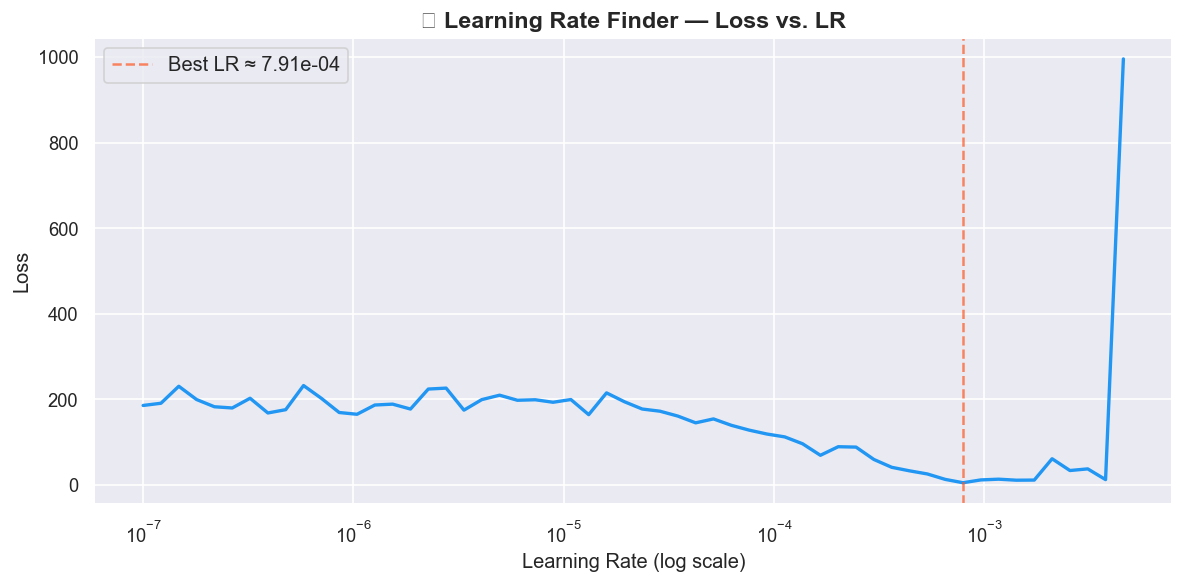


💡 Suggested optimal LR range: ~2.64e-04 to 2.37e-03


In [7]:
# Learning Rate Finder (mini sweep)
# Exponentially increase LR over one epoch and record loss to find optimal range

lr_finder_model = IELTSMultiTaskModel(n_extra_features=feats_scaled.shape[1]).to(device)
lr_finder_opt   = AdamW(lr_finder_model.parameters(), lr=1e-7)

lr_min, lr_max = 1e-7, 1e-2
num_steps = len(train_loader)
gamma = (lr_max / lr_min) ** (1 / num_steps)

lrs_sweep, losses_sweep = [], []
current_lr = lr_min

lr_finder_model.train()
print(f'🔍 Running LR Finder over {num_steps} steps (lr: {lr_min:.0e} → {lr_max:.0e})...')

for batch in train_loader:
    lr_finder_opt.zero_grad()
    ids  = batch['ids'].to(device)
    mask = batch['mask'].to(device)
    f    = batch['feats'].to(device)
    t    = batch['targets'].to(device)

    (ta, cc, lr_out, gra), _ = lr_finder_model(ids, mask, f)
    loss = (loss_fn(ta.squeeze(), t[:, 0]) + loss_fn(cc.squeeze(), t[:, 1]) +
            loss_fn(lr_out.squeeze(), t[:, 2]) + loss_fn(gra.squeeze(), t[:, 3]))

    loss.backward()
    lr_finder_opt.step()

    lrs_sweep.append(current_lr)
    losses_sweep.append(loss.item())

    # Increase LR exponentially
    current_lr *= gamma
    for pg in lr_finder_opt.param_groups:
        pg['lr'] = current_lr

    if loss.item() > 4 * losses_sweep[0]:  # Stop if loss explodes
        break

# Plot LR Finder
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lrs_sweep, losses_sweep, color='#2196F3', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)')
ax.set_ylabel('Loss')
ax.set_title('🔍 Learning Rate Finder — Loss vs. LR', fontsize=14, fontweight='bold')

# Mark the sweet spot
best_idx = np.argmin(losses_sweep)
ax.axvline(lrs_sweep[best_idx], color='#FF5722', linestyle='--', alpha=0.7,
           label=f'Best LR ≈ {lrs_sweep[best_idx]:.2e}')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n💡 Suggested optimal LR range: ~{lrs_sweep[best_idx]/3:.2e} to {lrs_sweep[best_idx]*3:.2e}')

del lr_finder_model  # Free memory

---
## 3. Training & Validation Accuracy per Epoch

In [9]:
# Training Loop with Validation Tracking

def evaluate_model(model, loader, loss_fn, device):
    """Run model on a DataLoader and return loss + per-criterion metrics."""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            f    = batch['feats'].to(device)
            t    = batch['targets'].to(device)

            (ta, cc, lr_out, gra), _ = model(ids, mask, f)
            loss = (loss_fn(ta.squeeze(), t[:, 0]) + loss_fn(cc.squeeze(), t[:, 1]) +
                    loss_fn(lr_out.squeeze(), t[:, 2]) + loss_fn(gra.squeeze(), t[:, 3]))
            total_loss += loss.item()

            preds = torch.stack([ta.squeeze(), cc.squeeze(),
                                 lr_out.squeeze(), gra.squeeze()], dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(t.cpu().numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    avg_loss = total_loss / len(loader)

    metrics = {}
    for i, name in enumerate(CRITERIA_SHORT):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        diff = np.abs(np.round(y_pred[:, i] * 2) / 2 - y_true[:, i])
        within_half = (diff <= 0.5).mean() * 100
        metrics[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Within_0.5': within_half}

    return avg_loss, metrics

In [10]:
# Run Training
history = {
    'train_loss': [], 'val_loss': [],
    'lr_log': [], 'step_lr': [],
}
for name in CRITERIA_SHORT:
    history[f'train_{name}_MAE']  = []
    history[f'val_{name}_MAE']    = []
    history[f'val_{name}_RMSE']   = []
    history[f'val_{name}_R2']     = []
    history[f'val_{name}_Acc0.5'] = []

global_step = 0

print(f'🚀 Training for {NUM_EPOCHS} epochs  |  LR={LR}  |  Batch={BATCH_SIZE}')
print('=' * 70)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        ids  = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        f    = batch['feats'].to(device)
        t    = batch['targets'].to(device)

        (ta, cc, lr_out, gra), _ = model(ids, mask, f)
        loss = (loss_fn(ta.squeeze(), t[:, 0]) + loss_fn(cc.squeeze(), t[:, 1]) +
                loss_fn(lr_out.squeeze(), t[:, 2]) + loss_fn(gra.squeeze(), t[:, 3]))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Log LR at each step
        history['lr_log'].append(optimizer.param_groups[0]['lr'])
        history['step_lr'].append(global_step)
        global_step += 1

    avg_train_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Evaluate on train set (for overfit detection)
    _, train_metrics = evaluate_model(model, train_loader, loss_fn, device)
    for name in CRITERIA_SHORT:
        history[f'train_{name}_MAE'].append(train_metrics[name]['MAE'])

    # Evaluate on validation set
    val_loss, val_metrics = evaluate_model(model, val_loader, loss_fn, device)
    history['val_loss'].append(val_loss)
    for name in CRITERIA_SHORT:
        history[f'val_{name}_MAE'].append(val_metrics[name]['MAE'])
        history[f'val_{name}_RMSE'].append(val_metrics[name]['RMSE'])
        history[f'val_{name}_R2'].append(val_metrics[name]['R2'])
        history[f'val_{name}_Acc0.5'].append(val_metrics[name]['Within_0.5'])

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}  '
          f'| Train Loss: {avg_train_loss:.4f}  '
          f'| Val Loss: {val_loss:.4f}  '
          f'| Val Acc(±0.5): '
          + '  '.join(f'{n}={val_metrics[n]["Within_0.5"]:.1f}%' for n in CRITERIA_SHORT))

print('\n Training complete!')

🚀 Training for 5 epochs  |  LR=1e-05  |  Batch=8
Epoch 1/5  | Train Loss: 143.1279  | Val Loss: 90.8997  | Val Acc(±0.5): TA=0.0%  CC=0.0%  LR=0.0%  GRA=0.0%
Epoch 2/5  | Train Loss: 75.4507  | Val Loss: 48.5833  | Val Acc(±0.5): TA=2.6%  CC=6.0%  LR=10.3%  GRA=12.0%
Epoch 3/5  | Train Loss: 43.0145  | Val Loss: 27.7930  | Val Acc(±0.5): TA=18.8%  CC=18.8%  LR=27.4%  GRA=26.5%
Epoch 4/5  | Train Loss: 26.1800  | Val Loss: 17.7513  | Val Acc(±0.5): TA=33.3%  CC=21.4%  LR=20.5%  GRA=33.3%
Epoch 5/5  | Train Loss: 17.5229  | Val Loss: 12.8958  | Val Acc(±0.5): TA=20.5%  CC=25.6%  LR=25.6%  GRA=26.5%

 Training complete!


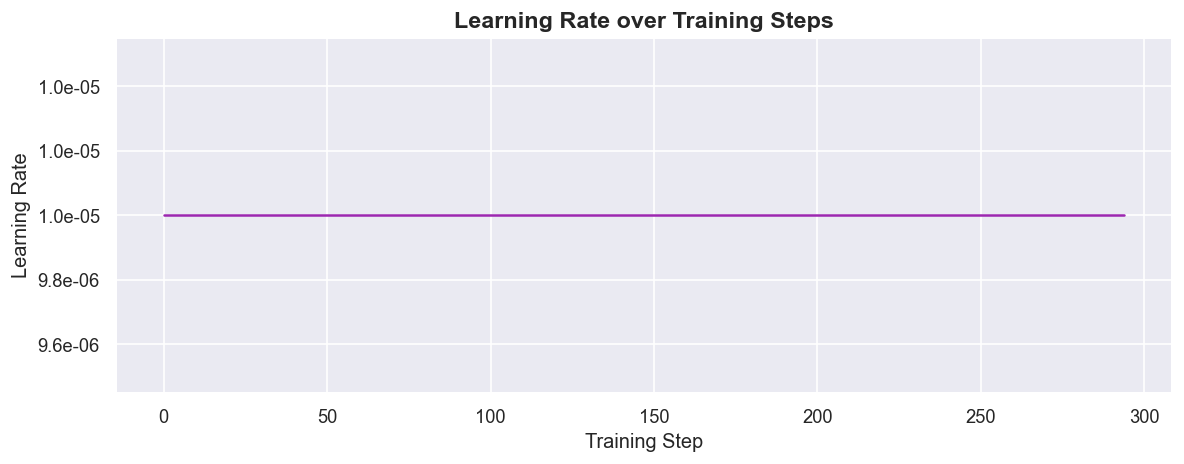

In [11]:
# Plot: LR over Training Steps
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['step_lr'], history['lr_log'], color='#9C27B0', linewidth=1.5)
ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate over Training Steps', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
plt.tight_layout()
plt.show()

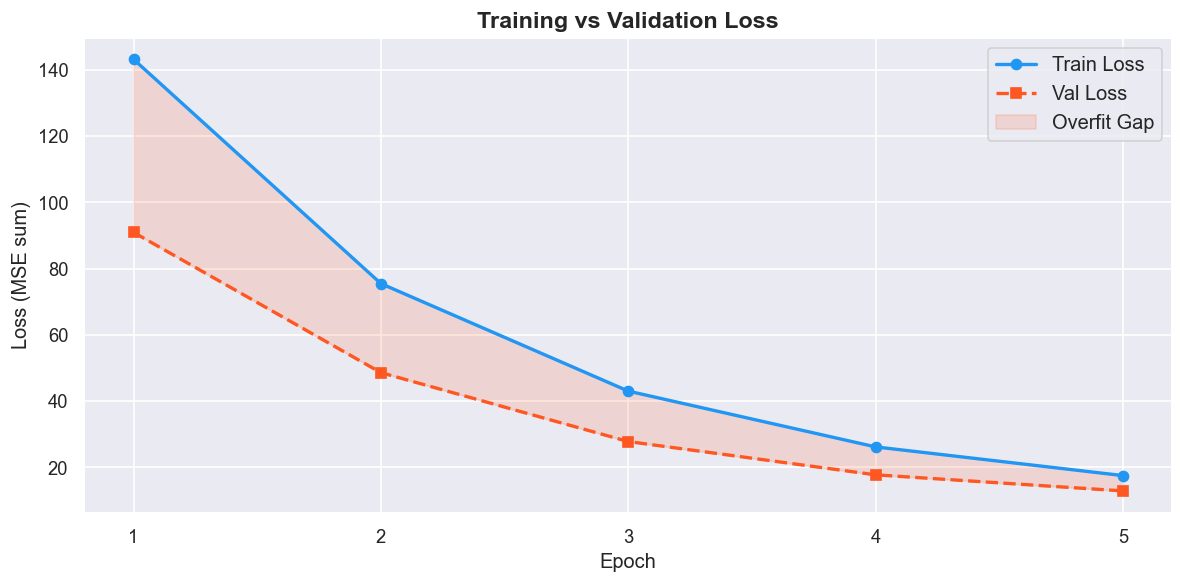

In [12]:
# Plot: Train vs Val Loss 
epochs_range = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_range, history['train_loss'], 'o-', color='#2196F3', linewidth=2, label='Train Loss')
ax.plot(epochs_range, history['val_loss'],   's--', color='#FF5722', linewidth=2, label='Val Loss')
ax.fill_between(epochs_range, history['train_loss'], history['val_loss'],
                alpha=0.15, color='#FF5722', label='Overfit Gap')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE sum)')
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xticks(list(epochs_range))
plt.tight_layout()
plt.show()

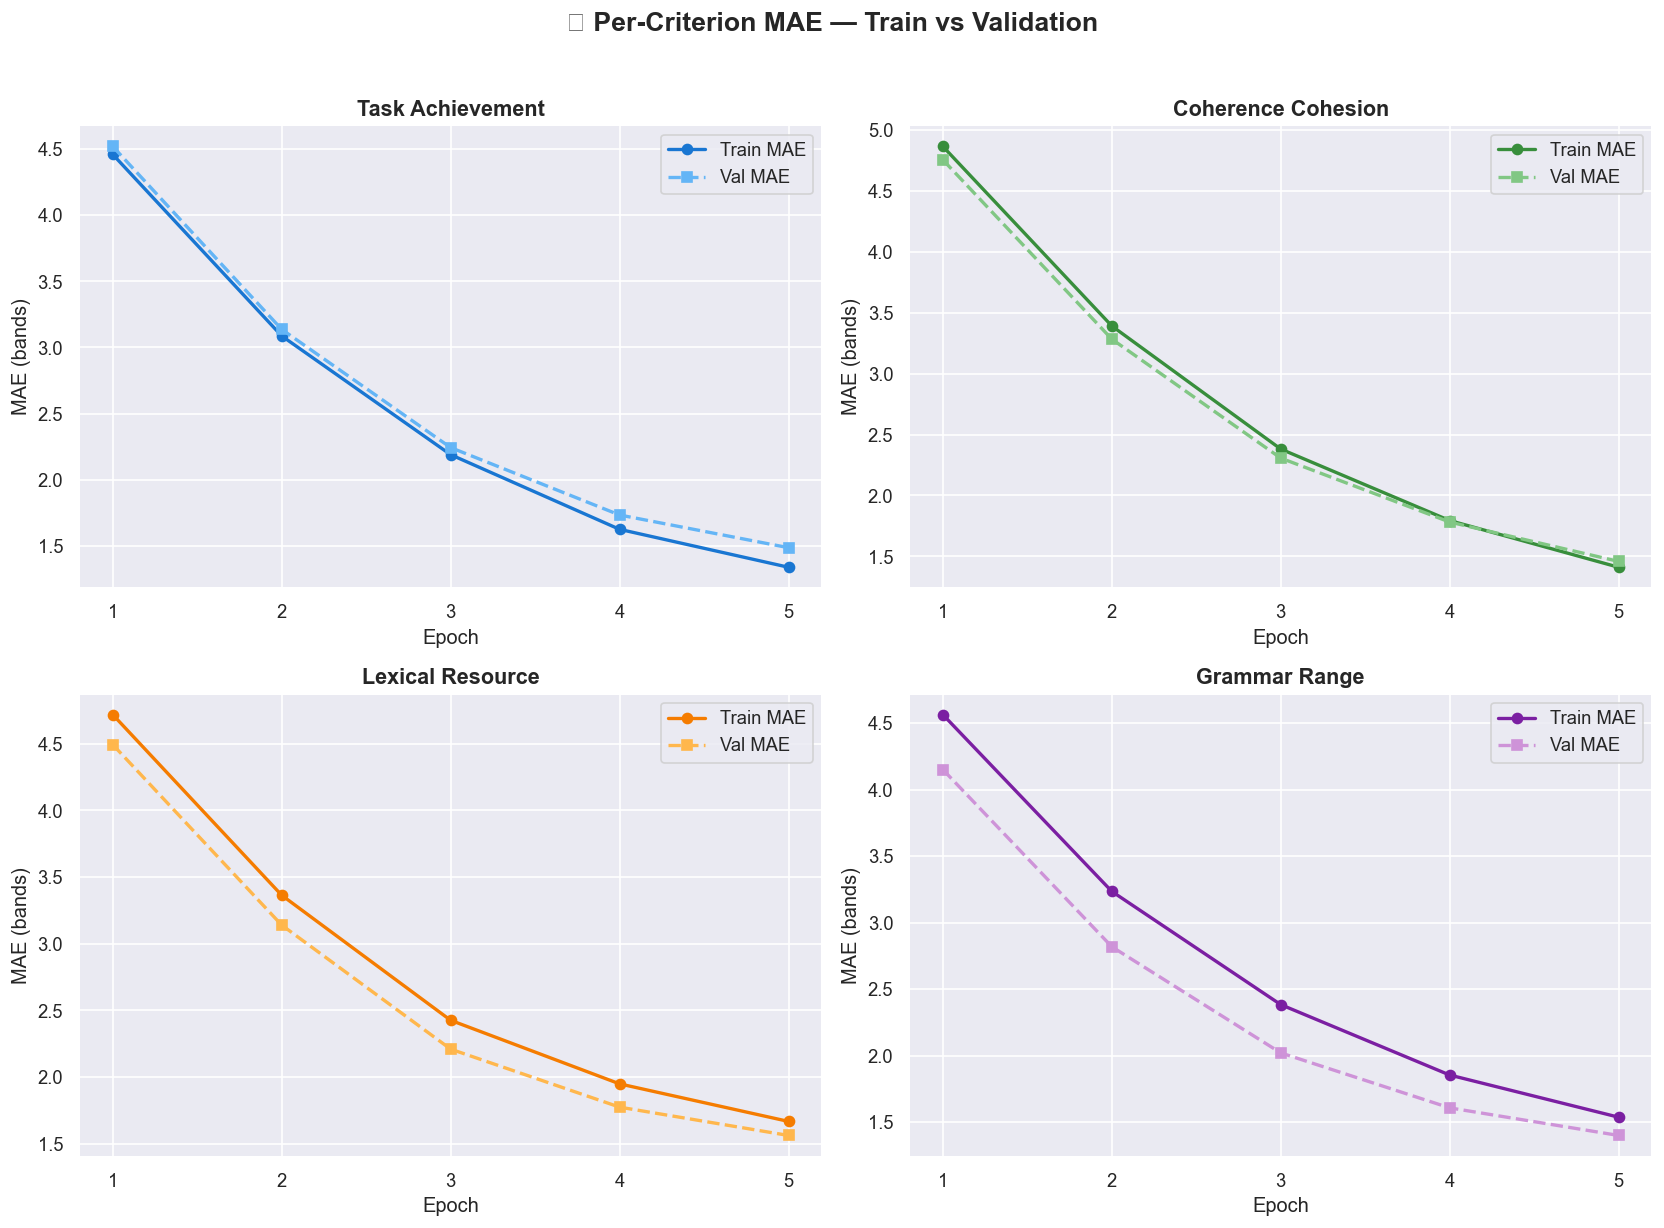

In [13]:
# Plot: Per-Criterion MAE (Train vs Val)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Per-Criterion MAE — Train vs Validation', fontsize=16, fontweight='bold', y=1.02)

colors_train = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
colors_val   = ['#64B5F6', '#81C784', '#FFB74D', '#CE93D8']

for idx, (name, full_name) in enumerate(zip(CRITERIA_SHORT, CRITERIA)):
    ax = axes[idx // 2][idx % 2]
    ax.plot(epochs_range, history[f'train_{name}_MAE'], 'o-',
            color=colors_train[idx], linewidth=2, label='Train MAE')
    ax.plot(epochs_range, history[f'val_{name}_MAE'], 's--',
            color=colors_val[idx], linewidth=2, label='Val MAE')
    ax.set_title(full_name.replace('_', ' '), fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE (bands)')
    ax.legend()
    ax.set_xticks(list(epochs_range))

plt.tight_layout()
plt.show()

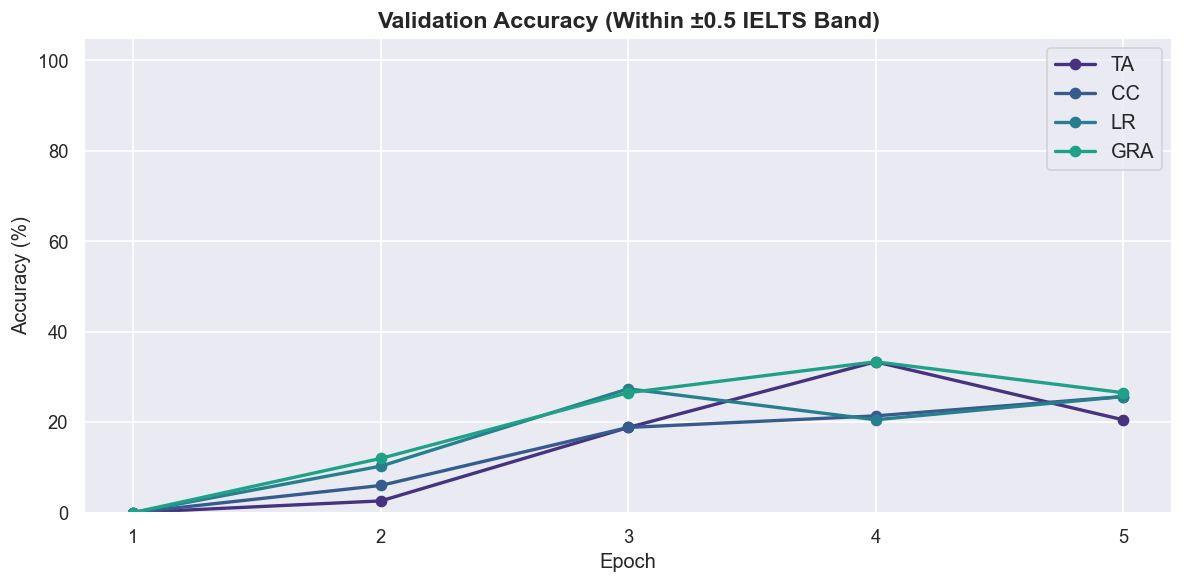

In [14]:
# Plot: Val Accuracy Within ±0.5 Band (all criteria)
fig, ax = plt.subplots(figsize=(10, 5))

for idx, name in enumerate(CRITERIA_SHORT):
    ax.plot(epochs_range, history[f'val_{name}_Acc0.5'], 'o-',
            linewidth=2, label=name)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy (Within ±0.5 IELTS Band)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xticks(list(epochs_range))
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [15]:
# Summary Table of Final Epoch Metrics 
summary_rows = []
for name, full_name in zip(CRITERIA_SHORT, CRITERIA):
    summary_rows.append({
        'Criterion': full_name.replace('_', ' '),
        'Train MAE': f"{history[f'train_{name}_MAE'][-1]:.3f}",
        'Val MAE':   f"{history[f'val_{name}_MAE'][-1]:.3f}",
        'Val RMSE':  f"{history[f'val_{name}_RMSE'][-1]:.3f}",
        'Val R²':    f"{history[f'val_{name}_R2'][-1]:.3f}",
        'Val Acc (±0.5)': f"{history[f'val_{name}_Acc0.5'][-1]:.1f}%"
    })

summary_df = pd.DataFrame(summary_rows)
print('Final Epoch Validation Metrics')
summary_df

Final Epoch Validation Metrics


,Criterion,Train MAE,Val MAE,Val RMSE,Val R²,Val Acc (±0.5)
0,Task Achievement,1.337,1.485,1.793,-0.537,20.5%
1,Coherence Cohesion,1.411,1.459,1.766,-0.412,25.6%
2,Lexical Resource,1.668,1.562,1.853,-0.221,25.6%
3,Grammar Range,1.537,1.400,1.700,-0.131,26.5%


---
## 4. Weights & Biases Inspection

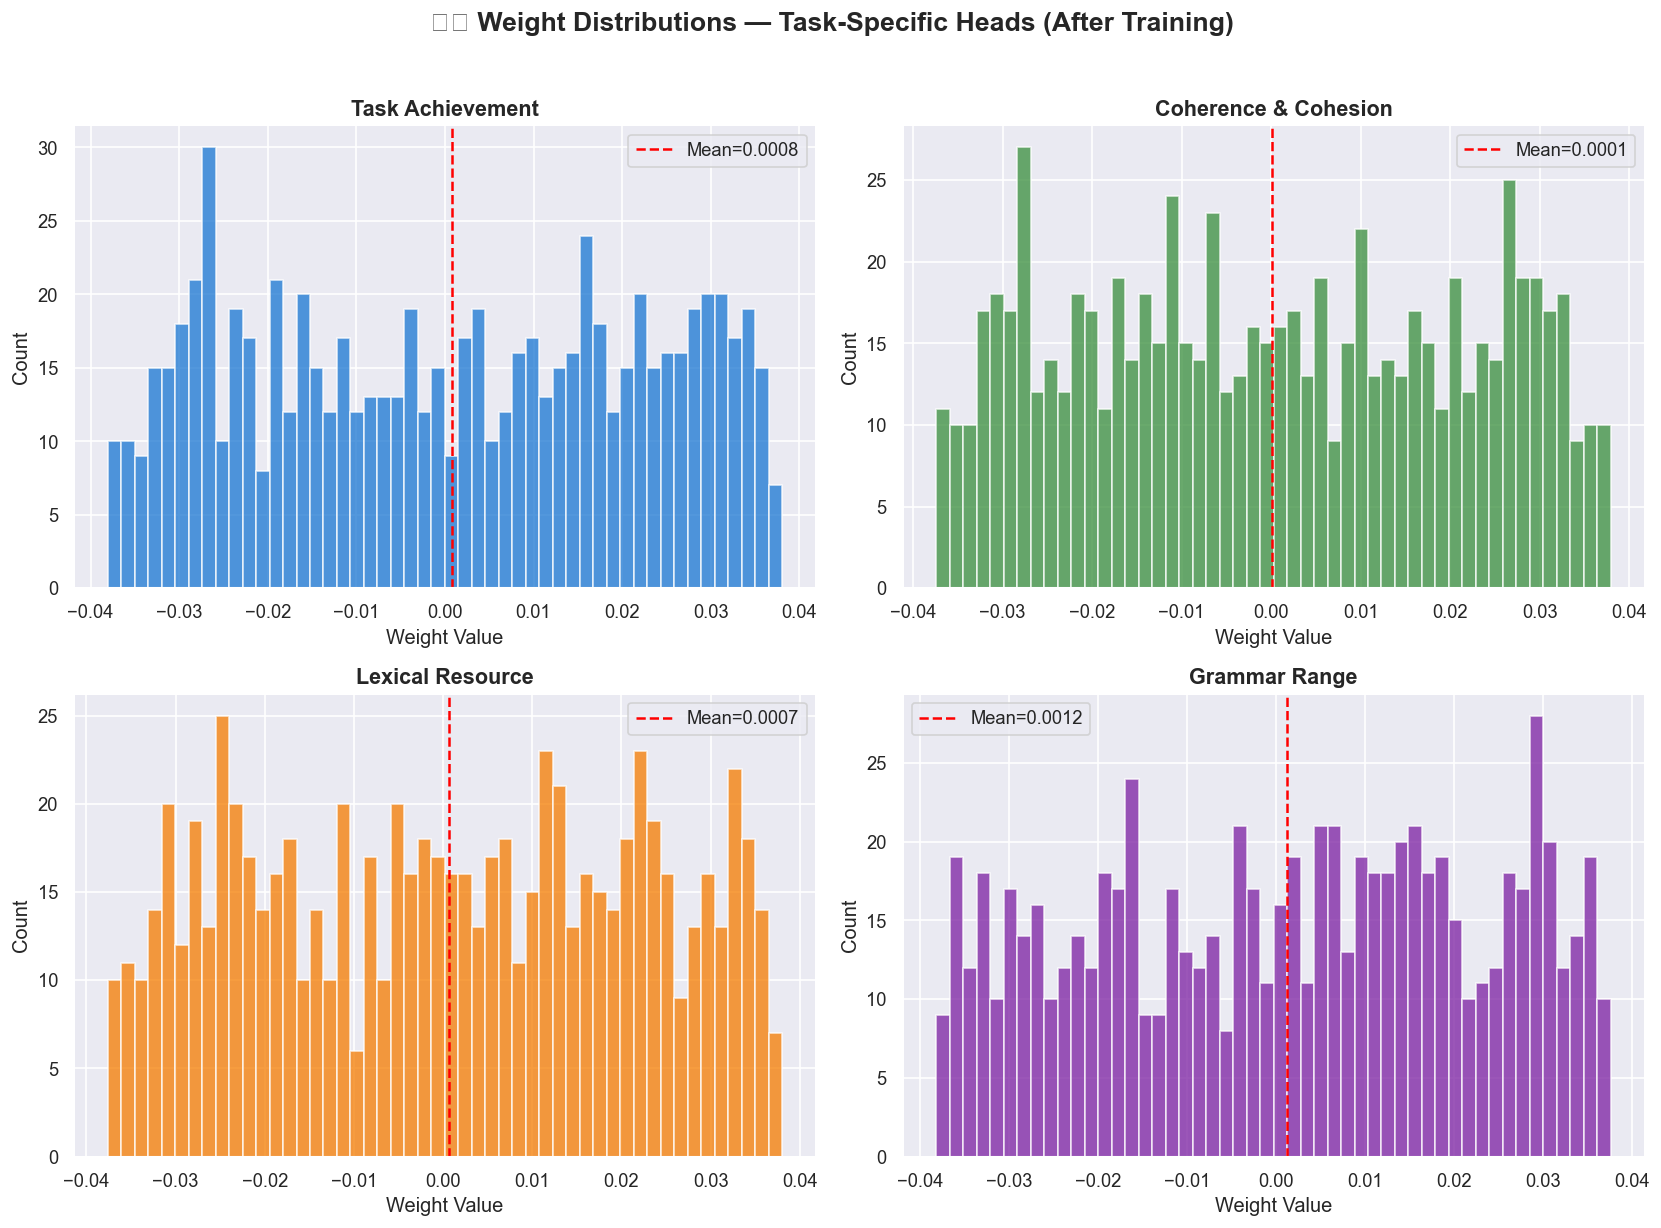

In [16]:
# Weight Distributions of Task-Specific Heads
head_names = ['ta_head', 'cc_head', 'lr_head', 'gra_head']
head_labels = ['Task Achievement', 'Coherence & Cohesion', 'Lexical Resource', 'Grammar Range']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('⚖️ Weight Distributions — Task-Specific Heads (After Training)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, (hname, hlabel) in enumerate(zip(head_names, head_labels)):
    ax = axes[idx // 2][idx % 2]
    layer = getattr(model, hname)
    weights = layer.weight.data.cpu().numpy().flatten()

    ax.hist(weights, bins=50, color=colors_train[idx], alpha=0.75, edgecolor='white')
    ax.axvline(weights.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean={weights.mean():.4f}')
    ax.set_title(hlabel, fontsize=13, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

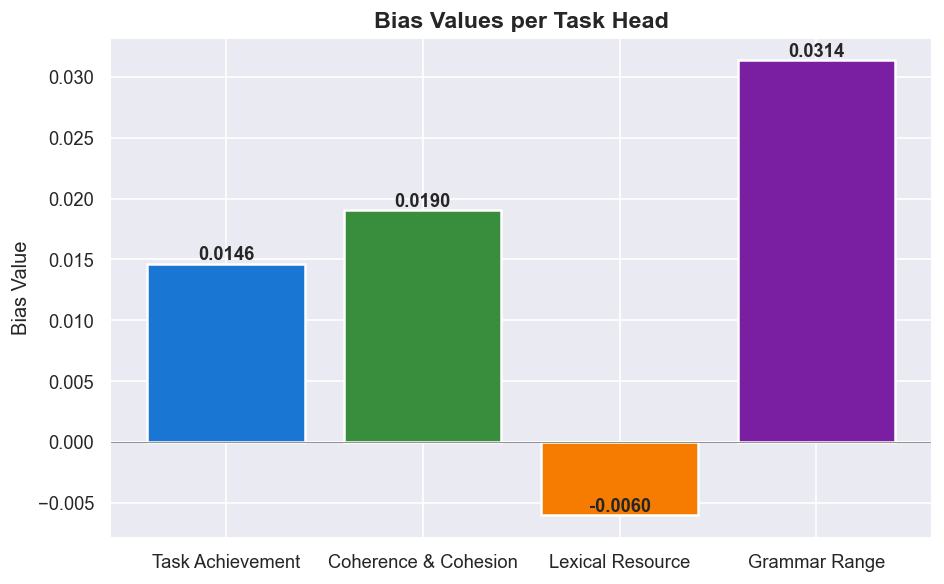

In [17]:
# Bias Values Across Heads
bias_data = {}
for hname, hlabel in zip(head_names, head_labels):
    layer = getattr(model, hname)
    bias_data[hlabel] = layer.bias.data.cpu().item()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bias_data.keys(), bias_data.values(),
              color=['#1976D2', '#388E3C', '#F57C00', '#7B1FA2'],
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, bias_data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Bias Value')
ax.set_title('Bias Values per Task Head', fontsize=14, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

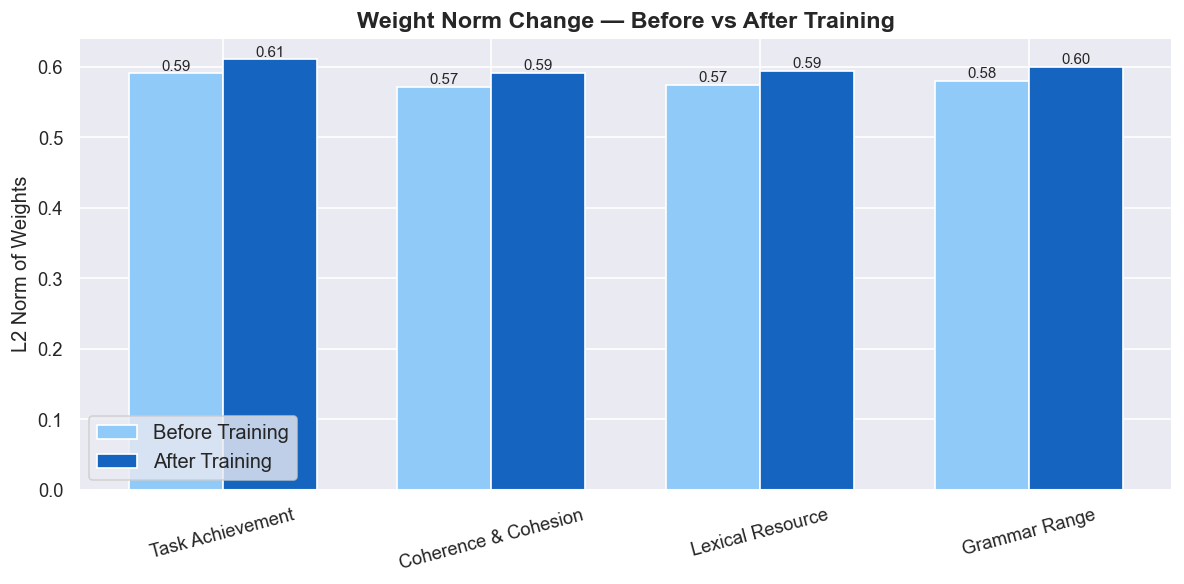

Weight Norm Deltas (After − Before):
           Task Achievement: +0.0199  (grew)
       Coherence & Cohesion: +0.0196  (grew)
           Lexical Resource: +0.0192  (grew)
              Grammar Range: +0.0198  (grew)


In [18]:
# Weight Norm Comparison: Before vs After Training
norm_before, norm_after = [], []

for hname in head_names:
    w_before = initial_state[f'{hname}.weight'].cpu().numpy()
    w_after  = getattr(model, hname).weight.data.cpu().numpy()
    norm_before.append(np.linalg.norm(w_before))
    norm_after.append(np.linalg.norm(w_after))

x = np.arange(len(head_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, norm_before, width, label='Before Training',
               color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x + width/2, norm_after, width, label='After Training',
               color='#1565C0', edgecolor='white')

ax.set_ylabel('L2 Norm of Weights')
ax.set_title('Weight Norm Change — Before vs After Training', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(head_labels, rotation=15)
ax.legend(fontsize=12)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print delta
print('Weight Norm Deltas (After − Before):')
for label, nb, na in zip(head_labels, norm_before, norm_after):
    delta = na - nb
    print(f'  {label:>25s}: {delta:+.4f}  ({"grew" if delta > 0 else "shrunk"})')

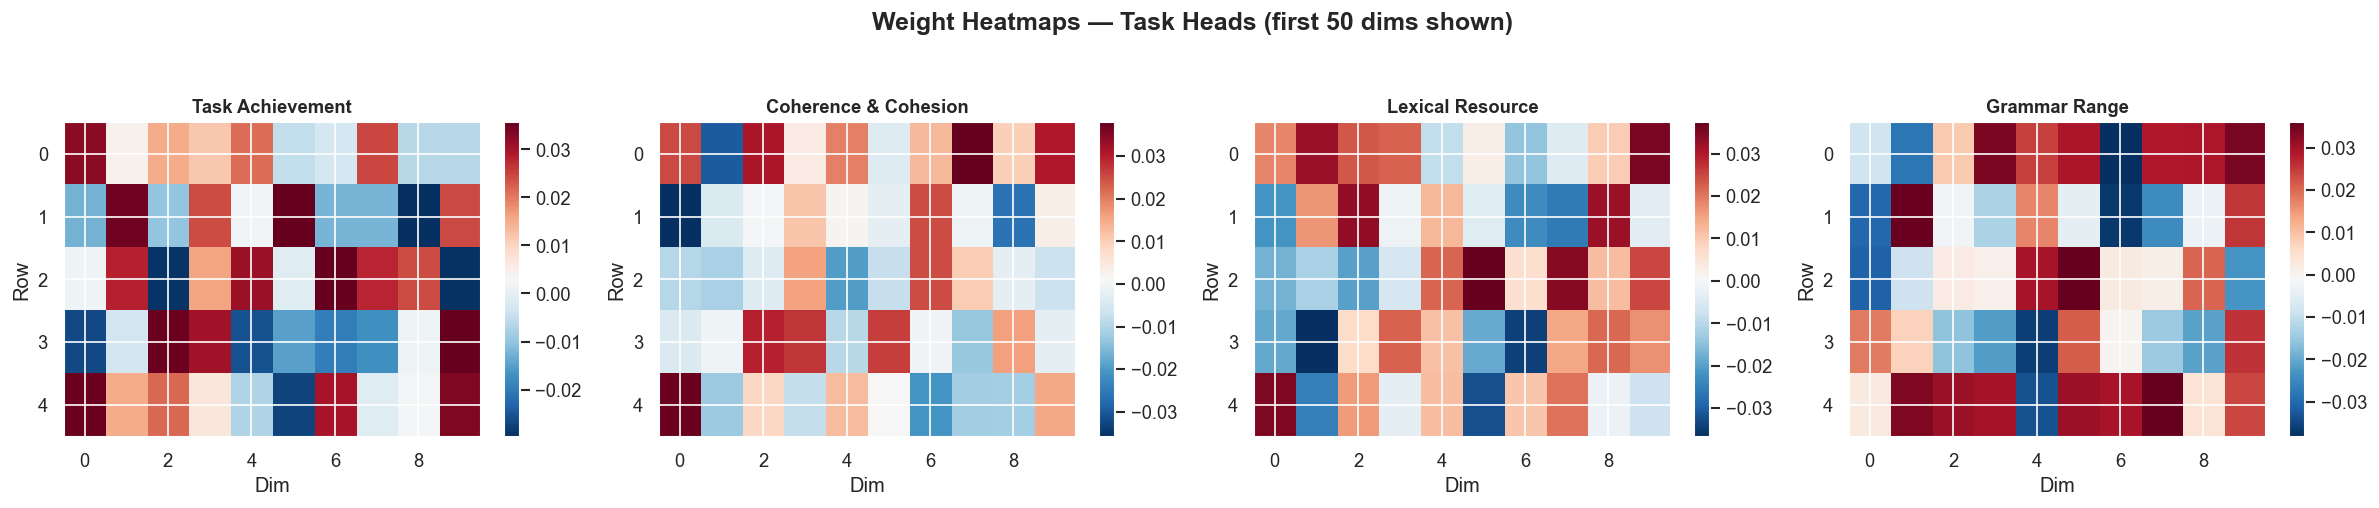

In [19]:
# Heatmap: All Head Weights Side-by-Side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Weight Heatmaps — Task Heads (first 50 dims shown)',
             fontsize=15, fontweight='bold', y=1.05)

for idx, (hname, hlabel) in enumerate(zip(head_names, head_labels)):
    w = getattr(model, hname).weight.data.cpu().numpy()  # Shape: (1, 773)
    # Reshape for visualization: show first 50 as a 5x10 grid
    w_vis = w[0, :50].reshape(5, 10)
    im = axes[idx].imshow(w_vis, cmap='RdBu_r', aspect='auto')
    axes[idx].set_title(hlabel, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Dim')
    axes[idx].set_ylabel('Row')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.tight_layout()
plt.show()

---
## 5. Data Augmentation Analysis

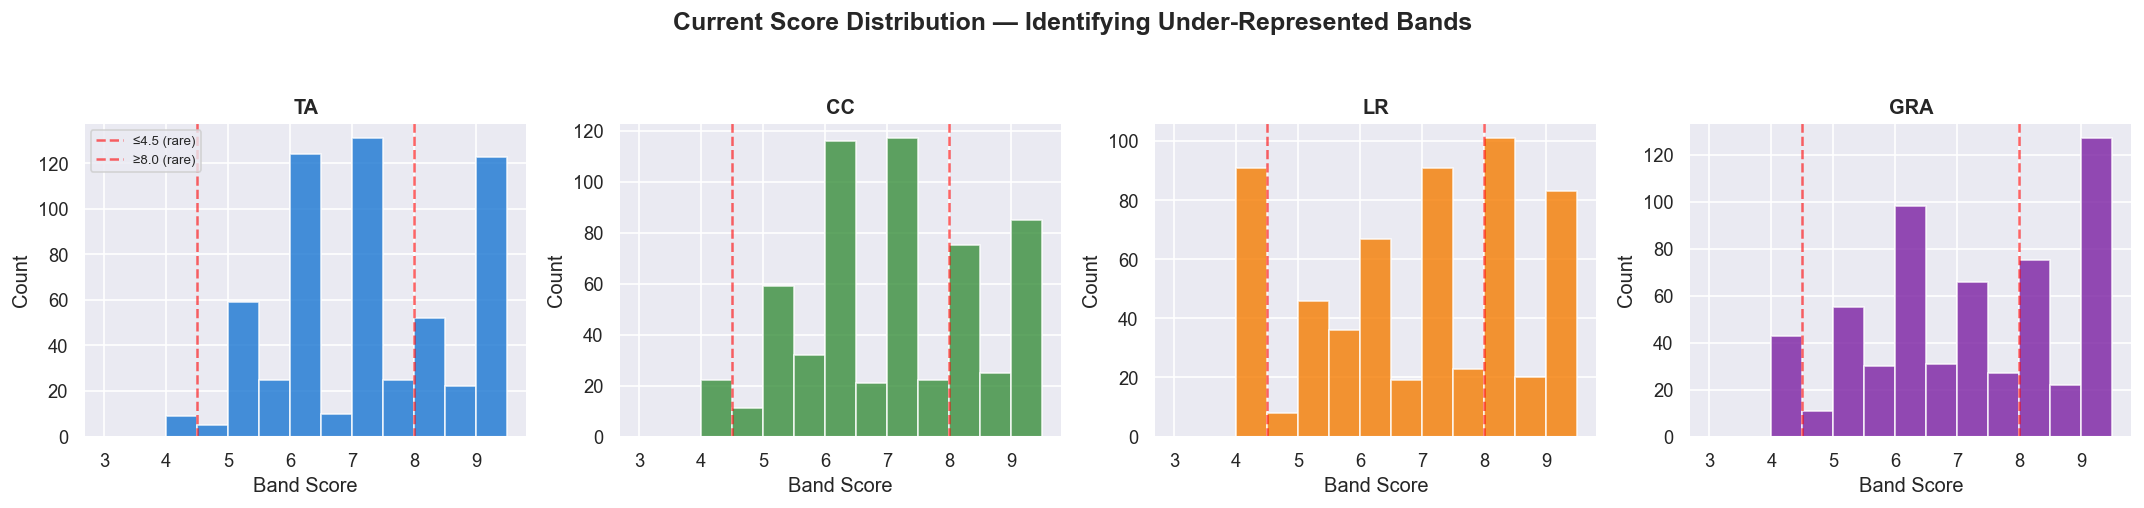

    Task_Achievement:  ≤4.5 = 14 (2.4%)  |  ≥8.0 = 197 (33.7%)
  Coherence_Cohesion:  ≤4.5 = 33 (5.6%)  |  ≥8.0 = 185 (31.6%)
    Lexical_Resource:  ≤4.5 = 99 (16.9%)  |  ≥8.0 = 204 (34.9%)
       Grammar_Range:  ≤4.5 = 54 (9.2%)  |  ≥8.0 = 224 (38.3%)


In [20]:
# Current Score Distribution
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Current Score Distribution — Identifying Under-Represented Bands',
             fontsize=15, fontweight='bold', y=1.05)

for idx, (crit, short) in enumerate(zip(CRITERIA, CRITERIA_SHORT)):
    ax = axes[idx]
    values = df[crit]
    ax.hist(values, bins=np.arange(3, 10, 0.5), color=colors_train[idx],
            alpha=0.8, edgecolor='white')
    ax.axvline(4.5, color='red', linestyle='--', alpha=0.6, label='≤4.5 (rare)')
    ax.axvline(8.0, color='red', linestyle='--', alpha=0.6, label='≥8.0 (rare)')
    ax.set_title(short, fontsize=12, fontweight='bold')
    ax.set_xlabel('Band Score')
    ax.set_ylabel('Count')
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Count rare samples
for crit in CRITERIA:
    low  = (df[crit] <= 4.5).sum()
    high = (df[crit] >= 8.0).sum()
    total = len(df)
    print(f'{crit:>20s}:  ≤4.5 = {low} ({low/total*100:.1f}%)  |  ≥8.0 = {high} ({high/total*100:.1f}%)')

In [28]:
# Synonym Substitution Augmentation 
import random
try:
    from nltk.corpus import wordnet
    import nltk
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    WORDNET_AVAILABLE = True
except ImportError:
    print('nltk not installed. Run: pip install nltk')
    WORDNET_AVAILABLE = False


def synonym_substitute(text, sub_rate=0.12):
    """Replace ~12% of words with WordNet synonyms."""
    if not WORDNET_AVAILABLE:
        return text
    doc = nlp(text)
    new_tokens = []
    for token in doc:
        if (token.is_alpha and not token.is_stop
            and random.random() < sub_rate and token.pos_ in ('NOUN', 'VERB', 'ADJ', 'ADV')):
            synsets = wordnet.synsets(token.text.lower())
            synonyms = set()
            for syn in synsets:
                for lemma in syn.lemmas():
                    if lemma.name().lower() != token.text.lower() and '_' not in lemma.name():
                        synonyms.add(lemma.name())
            if synonyms:
                replacement = random.choice(list(synonyms))
                new_tokens.append(replacement)
                continue
        new_tokens.append(token.text)
    return ' '.join(new_tokens)


# Demo
sample_text = df['Essay_Text'].iloc[0][:300]
augmented = synonym_substitute(sample_text)
print('=== Original (first 300 chars) ===')
print(sample_text[:200], '...')
print('\n=== Synonym Substituted ===')
print(augmented[:200], '...')

=== Original (first 300 chars) ===
The table compares the share of revenue which people spent on four categories, namely food, electronic and equipment, music and video in the UK in 1998. Overall , music was the highest proportion amon ...

=== Synonym Substituted ===
The remit compares the share of revenue which people spent on four categories , namely food , electronic and equipment , euphony and video in the UK in 1998 . Overall , euphony was the eminent proport ...


In [29]:
# Back-Translation Augmentation (Placeholder)
# NOTE: Back-translation requires a translation API or local model.
# Below is a template you can fill in with your preferred translation method.

def back_translate(text, source='en', pivot='fr'):
    """
    Template for back-translation augmentation.
    Replace this with a real translation call, e.g.:
    - Google Translate API
    - Helsinki-NLP/opus-mt models from HuggingFace
    - or any other translation service
    
    Example with transformers:
        from transformers import MarianMTModel, MarianTokenizer
        en_fr = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
        fr_en = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-fr-en')
    """
    # Placeholder: returns the original text
    # Replace with actual translation pipeline for real augmentation
    return text

print('Back-translation is set up as a template.')
print('   To activate, install a translation model and update the back_translate() function.')

Back-translation is set up as a template.
   To activate, install a translation model and update the back_translate() function.


In [30]:
# Augment Under-Represented Bands

# Identify essays with extreme scores (any criterion ≤4.5 or ≥8.0)
rare_mask = (df[CRITERIA] <= 4.5).any(axis=1) | (df[CRITERIA] >= 8.0).any(axis=1)
rare_df = df[rare_mask].copy()
print(f'📌 Rare-band essays found: {len(rare_df)} / {len(df)} ({len(rare_df)/len(df)*100:.1f}%)')

# Generate augmented versions via synonym substitution
if WORDNET_AVAILABLE and len(rare_df) > 0:
    augmented_rows = []
    for _, row in rare_df.iterrows():
        new_row = row.copy()
        new_row['Essay_Text'] = synonym_substitute(str(row['Essay_Text']), sub_rate=0.12)
        augmented_rows.append(new_row)

    aug_df = pd.DataFrame(augmented_rows)
    df_augmented = pd.concat([df, aug_df], ignore_index=True)
    print(f'Augmented dataset size: {len(df_augmented)} (added {len(aug_df)} synonym-augmented essays)')
else:
    df_augmented = df.copy()
    print('No augmentation applied (WordNet unavailable or no rare samples found)')

📌 Rare-band essays found: 387 / 585 (66.2%)
Augmented dataset size: 972 (added 387 synonym-augmented essays)


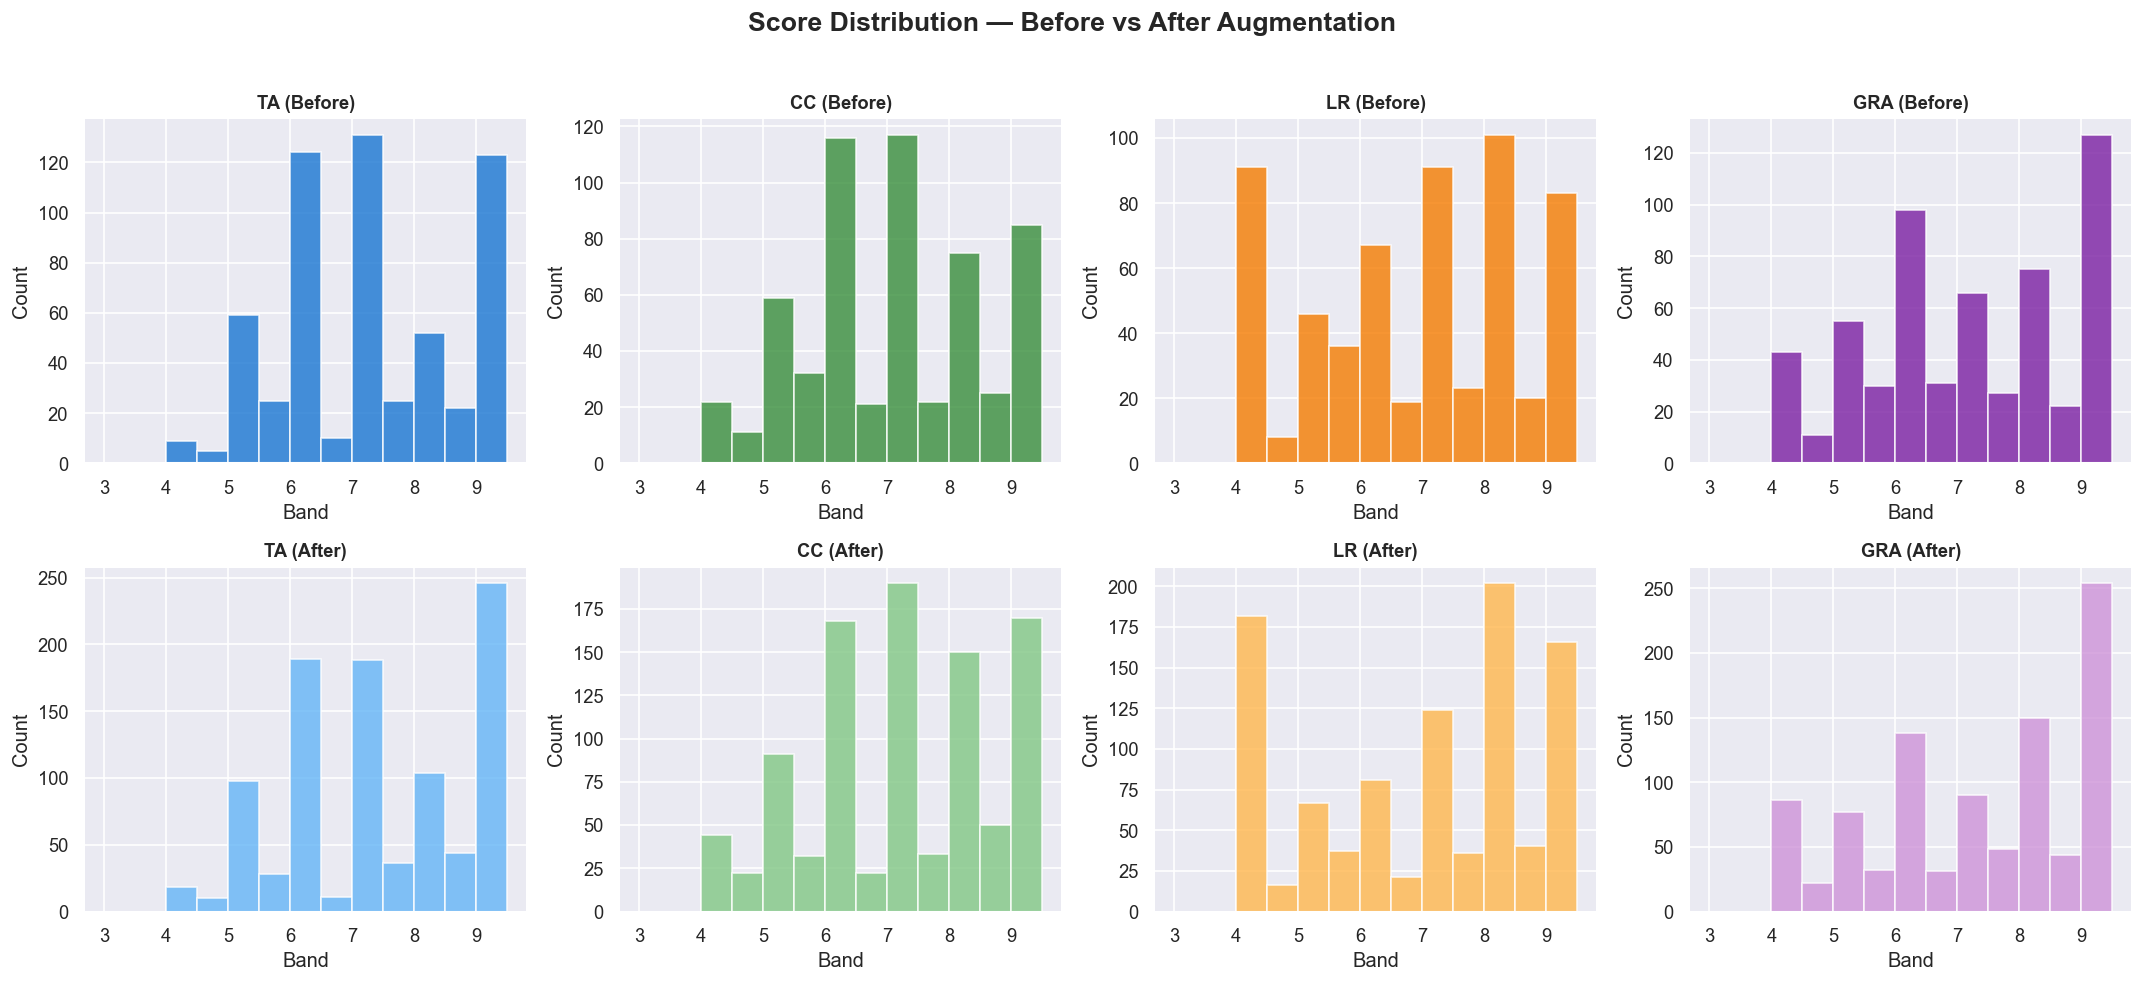

In [31]:
# Score Distribution: Before vs After Augmentation 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Score Distribution — Before vs After Augmentation',
             fontsize=16, fontweight='bold', y=1.02)

bins = np.arange(3, 10, 0.5)

for idx, (crit, short) in enumerate(zip(CRITERIA, CRITERIA_SHORT)):
    # Before
    ax = axes[0][idx]
    ax.hist(df[crit], bins=bins, color=colors_train[idx], alpha=0.8, edgecolor='white')
    ax.set_title(f'{short} (Before)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Band')
    ax.set_ylabel('Count')

    # After
    ax = axes[1][idx]
    ax.hist(df_augmented[crit], bins=bins, color=colors_val[idx], alpha=0.8, edgecolor='white')
    ax.set_title(f'{short} (After)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Band')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Checking cosine similarity for 20 original vs augmented essays...



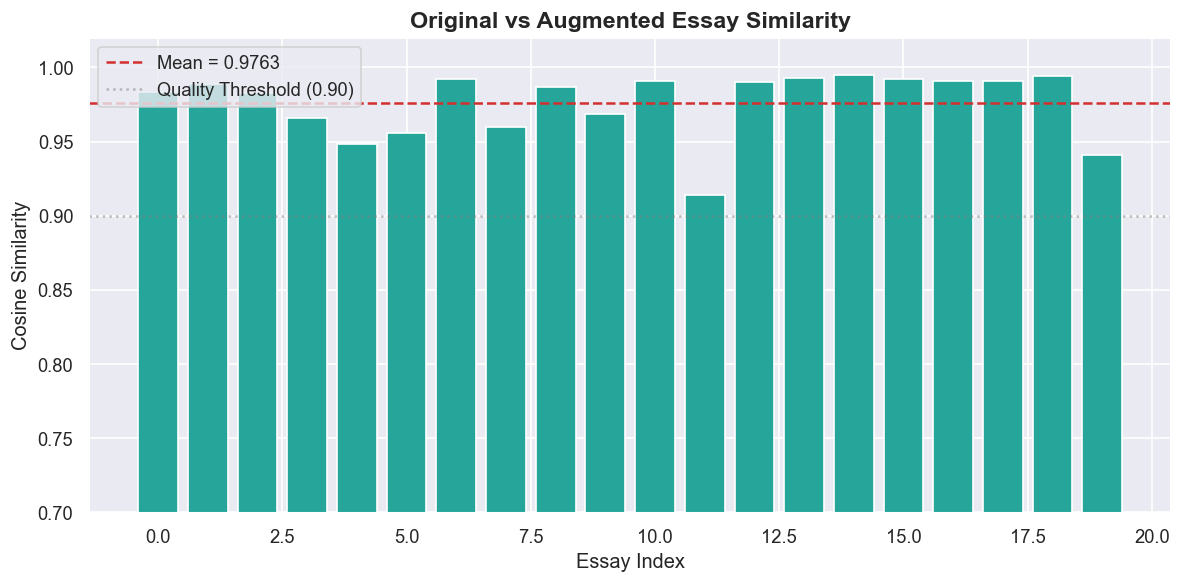


Similarity Stats:
   Mean:  0.9763
   Min:   0.9139
   Max:   0.9951
   Below 0.90: 0/20 (0%)


In [32]:
# Quality Check: Cosine Similarity of Original vs Augmented
if WORDNET_AVAILABLE and len(rare_df) > 0:
    n_check = min(20, len(rare_df))
    originals  = rare_df['Essay_Text'].iloc[:n_check].tolist()
    augmenteds = aug_df['Essay_Text'].iloc[:n_check].tolist()

    print(f'Checking cosine similarity for {n_check} original vs augmented essays...\n')
    
    orig_embs = sim_model.encode(originals, convert_to_numpy=True)
    aug_embs  = sim_model.encode(augmenteds, convert_to_numpy=True)

    similarities = []
    for i in range(n_check):
        sim_score = util.cos_sim(orig_embs[i], aug_embs[i]).item()
        similarities.append(sim_score)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(n_check), similarities, color='#26A69A', edgecolor='white')
    ax.axhline(np.mean(similarities), color='#D32F2F', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(similarities):.4f}')
    ax.axhline(0.90, color='gray', linestyle=':', alpha=0.5, label='Quality Threshold (0.90)')
    ax.set_xlabel('Essay Index')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title('Original vs Augmented Essay Similarity', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0.7, 1.02)
    plt.tight_layout()
    plt.show()

    print(f'\nSimilarity Stats:')
    print(f'   Mean:  {np.mean(similarities):.4f}')
    print(f'   Min:   {np.min(similarities):.4f}')
    print(f'   Max:   {np.max(similarities):.4f}')
    below_threshold = sum(1 for s in similarities if s < 0.90)
    print(f'   Below 0.90: {below_threshold}/{n_check} ({below_threshold/n_check*100:.0f}%)')
else:
    print('Skipping quality check — no augmented data available.')

---
## Summary

| Section | What It Tells You |
|---------|-------------------|
| **LR Finder** | Whether 1e-5 is actually the optimal learning rate |
| **Train vs Val Loss** | If the model is overfitting, underfitting, or well-balanced |
| **Per-Criterion MAE** | Which IELTS criteria the model struggles with most |
| **Weights & Biases** | How much each task head has learned and their parameter distributions |
| **Data Augmentation** | Whether augmenting rare-band essays improves class balance |

### Next Steps
- If the LR Finder suggests a different LR → re-run training with the new value
- If Train-Val gap is large → add regularization or reduce epochs
- If augmentation helps → integrate synonym substitute into `advanced_model.py`